Loading models and encoder from storage...
                 lr        l1        l2
precision  0.983815  0.983475  0.984142
recall     0.983819  0.983495  0.984142
fscore     0.983811  0.983484  0.984134
accuracy   0.983819  0.983495  0.984142
auc        0.990180  0.990003  0.990375


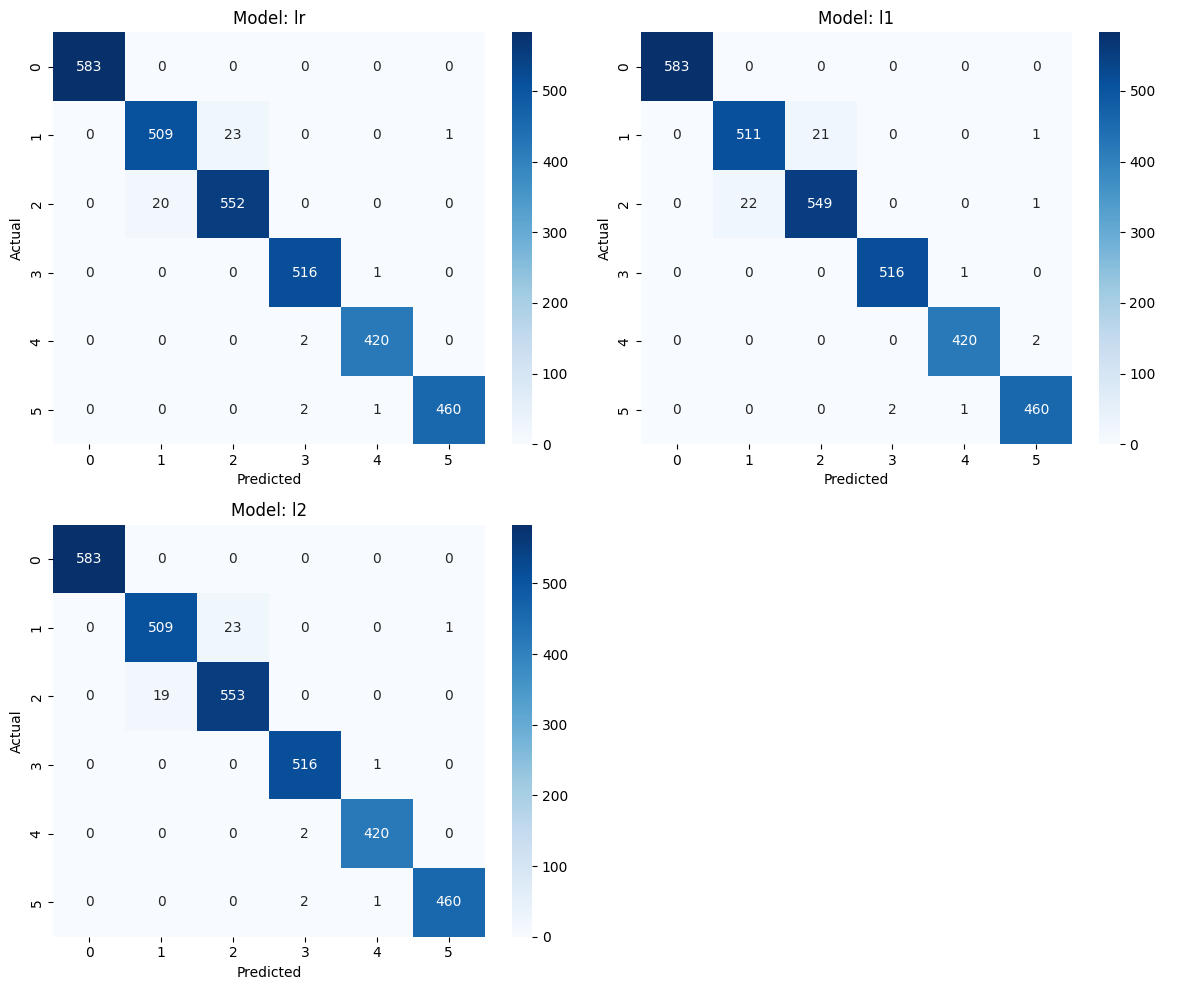

In [1]:
import seaborn as sns, pandas as pd
import matplotlib.pyplot as plt
import joblib, os
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

# 1. Setup and Persistence Configuration
MODEL_PATH = 'model_persistence/human_activity_full_package.pkl'

# Load data and initial LabelEncoding
data = pd.read_csv("data/Human_Activity_Recognition_Using_Smartphones_Data.csv")

# 2. Training/Loading Logic
if os.path.exists(MODEL_PATH):
    print("Loading models and encoder from storage...")
    storage = joblib.load(MODEL_PATH)
    le = storage['le']
    lr = storage['lr']
    lr_l1 = storage['l1']
    lr_l2 = storage['l2']
    data['Activity'] = le.transform(data['Activity'])
else:
    print("Training models... (Grab a coffee, this will take time)")
    le = LabelEncoder()
    data['Activity'] = le.fit_transform(data['Activity'])
    
    # Define Split
    feature_cols = data.columns[:-1]
    strat_shuf_split = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(strat_shuf_split.split(data[feature_cols], data.Activity))
    X_train, y_train = data.loc[train_idx, feature_cols], data.loc[train_idx, 'Activity']

    # Helper: Bundle Scaler + Model into a Pipeline
    def make_pipe(model_obj):
        return Pipeline([('scaler', StandardScaler()), ('model', model_obj)])

    # Fit Pipelines
    lr = make_pipe(LogisticRegression(solver='saga', max_iter=5000)).fit(X_train, y_train)
    lr_l1 = make_pipe(LogisticRegressionCV(Cs=10, cv=4, l1_ratios=(1,), use_legacy_attributes=False, solver='saga', max_iter=5000)).fit(X_train, y_train)
    lr_l2 = make_pipe(LogisticRegressionCV(Cs=10, cv=4, l1_ratios=(0,), use_legacy_attributes=False, solver='saga', max_iter=5000)).fit(X_train, y_train)

    # Save to one file
    joblib.dump({'lr': lr, 'l1': lr_l1, 'l2': lr_l2, 'le': le}, MODEL_PATH)

# 3. Predict & Generate Metrics (Always runs)
feature_cols = data.columns[:-1]
strat_shuf_split = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(strat_shuf_split.split(data[feature_cols], data.Activity))
X_test, y_test = data.loc[test_idx, feature_cols], data.loc[test_idx, 'Activity']

coeff_labels = ['lr', 'l1', 'l2']
coeff_models = [lr, lr_l1, lr_l2]

y_pred = pd.concat([pd.Series(m.predict(X_test), name=l) for l, m in zip(coeff_labels, coeff_models)], axis=1)

# 4. Calculation & Confusion Matrices
metrics = []
cm = {}

for lab in coeff_labels:
    precision, recall, fscore, _ = score(y_test, y_pred[lab], average='weighted')
    accuracy = accuracy_score(y_test, y_pred[lab])
    auc = roc_auc_score(label_binarize(y_test, classes=[0,1,2,3,4,5]),
                        label_binarize(y_pred[lab], classes=[0,1,2,3,4,5]), average='weighted')
    cm[lab] = confusion_matrix(y_test, y_pred[lab])
    metrics.append(pd.Series({'precision':precision, 'recall':recall, 'fscore':fscore, 'accuracy':accuracy, 'auc':auc}, name=lab))

# Final Display
print(pd.concat(metrics, axis=1))

# 5. Plotting
fig, axList = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axList = axList.flatten()
axList[-1].axis('off')

for ax, lab in zip(axList[:-1], coeff_labels):
    sns.heatmap(cm[lab], ax=ax, annot=True, fmt='d', cmap='Blues')
    ax.set(title=f'Model: {lab}', xlabel='Predicted', ylabel='Actual')
plt.tight_layout()